In [1]:
!uv pip install tensorflow

Resolved 32 packages in 10.89s
Prepared 21 packages in 4m 46s
Installed 24 packages in 30.07s
 + absl-py==2.4.0
 + astunparse==1.6.3
 + flatbuffers==25.12.19
 + gast==0.7.0
 + google-pasta==0.2.0
 + grpcio==1.81.0
 + h5py==3.14.0
 + keras==3.14.1
 + libclang==18.1.1
 + markdown-it-py==4.2.0
 + mdurl==0.1.2
 + ml-dtypes==0.5.4
 + namex==0.1.0
 + opt-einsum==3.4.0
 + optree==0.19.1
 + protobuf==7.35.0
 + pygments==2.20.0
 + rich==15.0.0
 + setuptools==82.0.1
 + tensorflow==2.21.0
 + termcolor==3.3.0
 + typing-extensions==4.15.0
 + wheel==0.47.0
 + wrapt==2.2.1


In [6]:
"""
任务1：
    1. 加载数据
    2. 数据归一化
    3. 数据变换
    4. 展示数据集基本信息
"""

# 导入 tensorflow.keras.datasets 自带 mnist
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
import numpy as np

# 加载数据
# 返回一个包含两个元组的元组 mnist.load_data()
# 外层元组：有两个元素， 分别是训练集和测试集
# 内层元组：每个内层元组有2个元组，分别是图像数据和标签数据
# (x_train, y_train) x_train 训练集的图像数据 y_train 训练集的标签
# (x_test, y_test) x_test 测试集的图像数据 y_test 测试集的标签
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 查看数据形状
print("="*50)
print("MNIST 数据集基本信息")
print("="*50)
print(f"训练集样本数量：{x_train.shape[0]}")
print(f"测试集样本数量：{x_test.shape[0]}")
print(f"图片原始尺寸：{x_train.shape[1]} x {x_train.shape[2]} 像素")
print(f"像素值范围：{x_train.min()} ~ {x_train.max()}")
print(f"标签范围：{y_train.min()} ~ {y_train.max()}")
print()

# 数据归一化 将像素值从 0~255 缩放到 0~1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 数据变换 有两种方法
# 方法一， 将28*28图像展平成784维向量（适用于全连接网络）
# 方法二，保留二维结构并增加通道维度 (28, 28, 1) (适用于卷积神经网络) (CNN常见)

# 增加通道维度 (样本数, 28, 28, 1)
x_train = x_train[..., np.newaxis]
x_test = x_test[..., np.newaxis]

# 标签转换: 将整数标签转为one-hot编码(用于分类交叉熵损失)
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("预处理后数据形状：")
print(f"训练集图像：{x_train.shape} (样本数， 高度， 宽度， 通道)")
print(f"训练集标签：{y_train.shape} (one-hot)")
print(f"测试集图像：{x_test.shape}")
print(f"测试集标签：{y_test.shape}")
print(f"像素值范围验证：{x_train.min():.2f} ~ {x_train.max():.2f}")



MNIST 数据集基本信息
训练集样本数量：60000
测试集样本数量：10000
图片原始尺寸：28 x 28 像素
像素值范围：0 ~ 255
标签范围：0 ~ 9

预处理后数据形状：
训练集图像：(60000, 28, 28, 1) (样本数， 高度， 宽度， 通道)
训练集标签：(60000, 10) (one-hot)
测试集图像：(10000, 28, 28, 1)
测试集标签：(10000, 10)
像素值范围验证：0.00 ~ 1.00


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten_6 (Flatten)                  │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9021 - loss: 0.3522 - val_accuracy: 0.9598 - val_loss: 0.1412
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9568 - loss: 0.1456 - val_accuracy: 0.9668 - val_loss: 0.1093
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9690 - loss: 0.1029 - val_accuracy: 0.9757 - val_loss: 0.0883
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9770 - loss: 0.0773 - val_accuracy: 0.9753 - val_loss: 0.0879
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0643 - val_accuracy: 0.9762 - val_loss: 0.0811
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9848 - loss: 0.0510 - val_accuracy: 0.9760 - val_loss: 0.0815
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9876 - loss: 0.0403 - val_accuracy: 0.9762 - val_loss: 0.0802
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9893 - loss: 0.0344 - val_accuracy: 0.

测试集准确率：0.9766


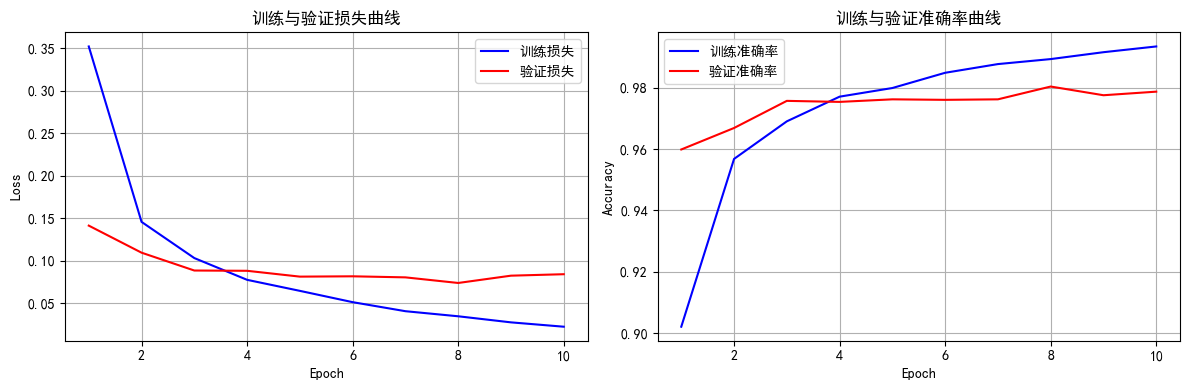

In [14]:
"""
    任务二 神经网络模型构建与训练任务：
        使用Keras框架构建一个全连接神经网络模型，用于手写数字识别。模型至少包含输入层，隐藏层和输出层。编写训练代码，设置合适的优化器，损失函数和评估指标。
        训练完成后保存模型到本地(如model.h5)。绘制包括损失和准确率变化曲线。
"""
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 构建全连接神经网络
model = Sequential([
    Flatten(input_shape=(28, 28)), # 输入层：将28*28图像展平成784维
    Dense(128, activation='relu'), # 隐藏层1：128个神经元
    Dense(64, activation='relu'), # 隐藏层2：64个神经元
    Dense(10, activation='softmax') # 输出层：10个类别    
])

# 显示模型结构
model.summary()
# 编译模型
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
# 训练模型
history = model.fit(
    x_train, y_train,
    batch_size= 128,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

# 在测试集上评估
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"测试集准确率：{test_acc:.4f}")

# 保存模型
model.save('model.h5') # 保存为HDF5格式

# 绘制训练过程中的损失和准确率曲线
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
epochs_range = range(1, len(train_loss) + 1)

plt.figure(figsize=(12, 4))

# 损失曲线
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_loss, 'b-', label='训练损失')
plt.plot(epochs_range, val_loss, 'r-', label='验证损失')
plt.title('训练与验证损失曲线')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# 准确率曲线
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_acc, 'b-', label= '训练准确率')
plt.plot(epochs_range, val_acc, 'r-', label= '验证准确率')
plt.title('训练与验证准确率曲线')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()


模型加载成功
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


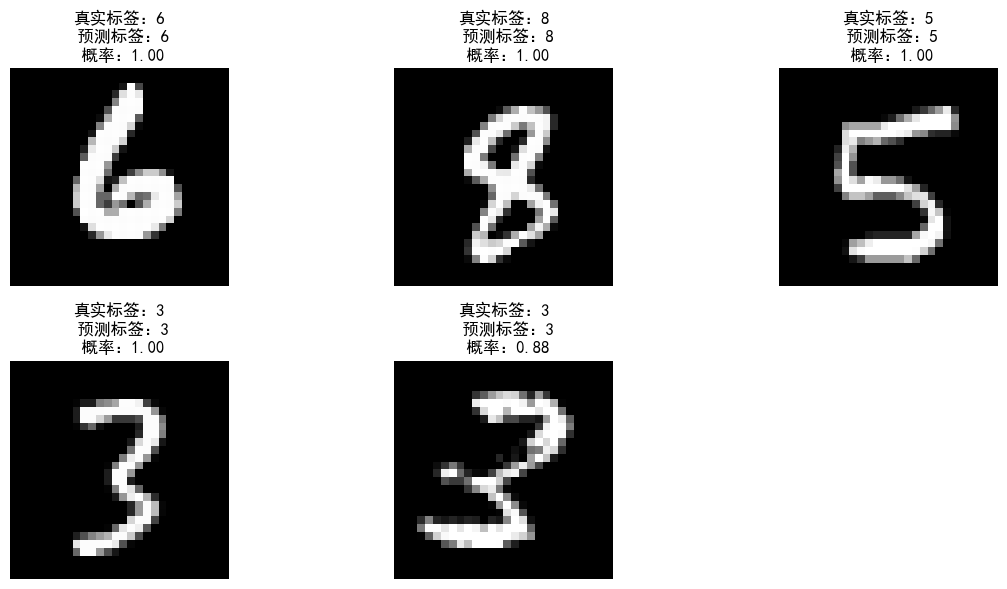

In [19]:
"""
    任务三：
        加载已保存模型，
        对测试集中图片进行预测，随机选中5张测试图片，展示每张图片以及真实标签和预测结果。将测试图片，预测结果和预测概率可视化展示
"""
from tensorflow.keras.models import load_model

# 加载已保存模型
model = load_model('model.h5')
print('模型加载成功')

# 加载MNIST测试集 (原始数据，未处理)
(_, _), (x_test, y_test) = mnist.load_data()

# 对训练集进行与训练师相同的预处理
x_test = x_test.astype('float32') / 255.0

# 随机选择5张测试图片
num_samples = 5
indices = np.random.choice(len(x_test), num_samples, replace=False)
sample_images = x_test[indices]
sample_labels = y_test[indices] # 真实标签
# 对选中的图片进行预测
predictions = model.predict(sample_images)
predicted_classes = np.argmax(predictions, axis=1) # 预测类别
predicted_probs = np.max(predictions, axis=1) # 最大概率值

# 使用matplotlib 可视化结果
plt.figure(figsize=(12,6))
for i in range(num_samples):
    plt.subplot(2, 3, i + 1)
    plt.imshow(sample_images[i], cmap='gray')
    plt.title(f"真实标签：{sample_labels[i]}\n 预测标签：{predicted_classes[i]}\n 概率：{predicted_probs[i]:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()